In [1]:
from random import random 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sn

In [2]:
def zad1(n):

    G = 0
    J = 0
    for _ in range(n):
        xs = ''
        for _ in range(20):
            
            x = random()
            if x >0.5:
                xs += 'O'
            else:
                xs += 'R'
        
            if xs.endswith('OOR'):
                J += 1
                break
            
            if xs.endswith('ORR'):
                G += 1
                break

    return G/n, J/n

print(zad1(1000))

(0.346, 0.654)


In [3]:
def zad2(G, J, n):

    G_bankrupt = 0
    J_bankrupt = 0
    
    for _ in range(n):
        xs = ''
        G_money, J_money = G, J
        
        while G_money > 0 and J_money > 0:
            if random() > 0.5:
                xs += 'O'
            else:
                xs += 'R'
        
            if xs.endswith('OOR'):
                J_money += 1
                G_money -= 1
                xs = ''
            elif xs.endswith('ORR'):
                G_money += 1
                J_money -= 1
                xs = ''
        
        G_bankrupt += G_money == 0
        J_bankrupt += J_money == 0

    return G_bankrupt / n, J_bankrupt / n

print(zad2(25, 5, 1000))

(0.97, 0.03)


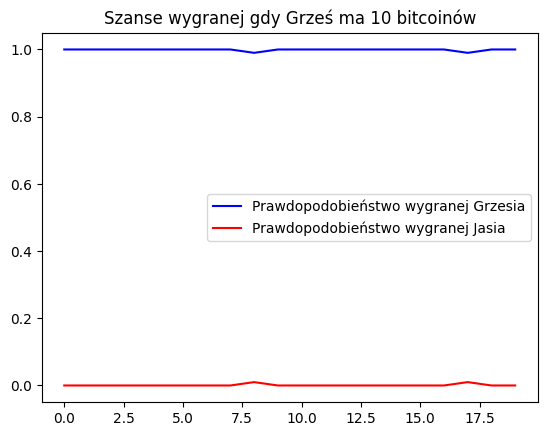

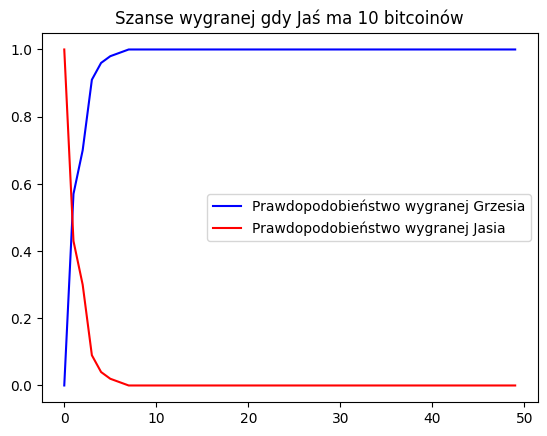

In [4]:
def zad3_g():
    
    wyniki_g, wyniki_j, liczba_b = [], [], range(20)
    
    for i in liczba_b:
        x, y = zad2(i, 10, 100)
        wyniki_g.append(x)
        wyniki_j.append(y)
    
    plt.plot(liczba_b, wyniki_g, color='blue', label='Prawdopodobieństwo wygranej Grzesia')
    plt.plot(liczba_b, wyniki_j, color='red', label='Prawdopodobieństwo wygranej Jasia')   
    plt.title('Szanse wygranej gdy Grześ ma 10 bitcoinów')
    plt.legend()
    plt.show()


def zad3_j():
   
    wyniki_g, wyniki_j, liczba_b = [], [], range(50)
    
    for i in liczba_b:
        x, y = zad2(10, i, 100)
        wyniki_g.append(x)
        wyniki_j.append(y)
    
    plt.plot(liczba_b, wyniki_g, color='blue', label='Prawdopodobieństwo wygranej Grzesia')
    plt.plot(liczba_b, wyniki_j, color='red', label='Prawdopodobieństwo wygranej Jasia')   
    plt.title('Szanse wygranej gdy Jaś ma 10 bitcoinów')
    plt.legend()
    plt.show()


zad3_g()
zad3_j()

In [5]:
def graj_dalej(P1, P2, Seq1, Seq2):
    P1_bankrupt = 0
    P2_bankrupt = 0

    xs = ''
    P1_money = P1
    P2_money = P2
    while P1_money > 0 and P2_money > 0:
            
        if random() >0.5:
            xs += 'O'
        else:
            xs += 'R'
    
        if xs.endswith(Seq1):
            P1_money += 1
            P2_money -= 1
            xs = ''
            
        if xs.endswith(Seq2):
            P2_money += 1
            P1_money -= 1
            xs = ''
    if P1_money == 0:
        P1_bankrupt += 1
    if P2_money == 0:
        P2_bankrupt += 1

    return P1_bankrupt, P2_bankrupt


def zad4(G, J, T, n):
    G_bankrupt = 0
    J_bankrupt = 0
    T_bankrupt = 0
    for _ in range(n):
        xs = ''
        G_money = G
        J_money = J
        T_money = T
        while G_money > 0 and J_money > 0 and T_money > 0:
            x = random()
            if x >0.5:
                xs += 'O'
            else:
                xs += 'R'
        
            if xs[-3:] == 'OOR':
                J_money += 2
                G_money -= 1
                T_money -= 1
                xs = ''
            
            if xs[-3:] == 'ORR':
                G_money += 2
                J_money -= 1
                T_money -= 1
                xs = ''

            if xs[-3:] == 'RRR':
                T_money += 2
                G_money -= 1
                J_money -= 1
                xs = ''

        if G_money == 0:
            G_bankrupt += 1
            y, z = graj_dalej(J_money, T_money,"OOR", "RRR")
            J_bankrupt += y
            T_bankrupt += z

        if J_money == 0:
            J_bankrupt += 1
            y, z = graj_dalej(G_money, T_money, "ORR", "RRR")
            G_bankrupt += y
            T_bankrupt += z
        if T_money == 0:
            T_bankrupt += 1
            y, z = graj_dalej(J_money, G_money, "OOR", "ORR")
            J_bankrupt += y
            G_bankrupt += z

    return G_bankrupt/n, J_bankrupt/n, T_bankrupt/n


print(zad4(25, 5, 50, 1000))   

(0.987, 0.013, 1.0)


In [7]:
def zad5(n):
    seq = ['OOO', 'OOR', 'ORO', 'ROO', 'ORR', 'RRO', 'ROR', 'RRR']
    for char1 in range(len(seq)):
        for char2 in range(char1, len(seq)):
            G = 0
            J = 0
            for _ in range(n):
                xs = ''
                for _ in range(25):
                    
                    if random() > 0.5:
                        xs += 'O'
                    else:
                        xs += 'R'
                
                    if xs.endswith(seq[char1]):
                        J += 1
                        break
                    
                    if xs.endswith(seq[char2]):
                        G += 1
                        break

            if abs(G/n - J/n) < 0.1:
                print(f'{seq[char1]} i {seq[char2]}')
                    
                

zad5(300)

OOO i OOR
OOO i RRR
OOR i RRO
ORO i ROO
ORO i ORR
ORO i ROR
ORO i RRR
ROO i ORR
ROO i ROR
ROO i RRR
ORR i ROR
RRO i RRR


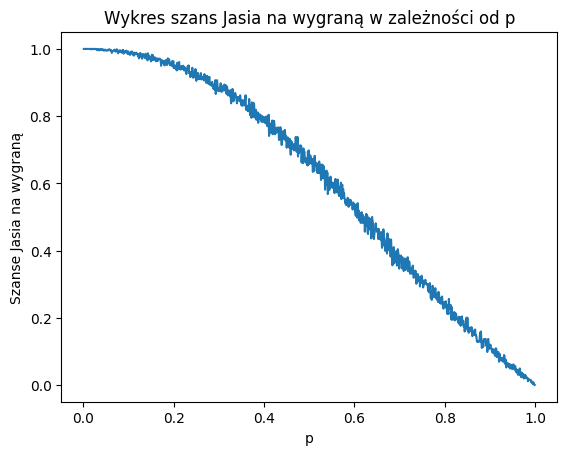

In [8]:
def zad7(p, n):

    G = 0
    J = 0
    for _ in range(n):
        xs = ''
        while True:
            
            if random() > p:
                xs += 'O'
            else:
                xs += 'R'
        
            if xs.endswith('OOR'):
                J += 1
                break
            
            if xs.endswith('ORR'):
                G += 1
                break

    return G/n, J/n


def fair_play(n):
    for i in range(1, n):

        wyniki = zad7(i/n, n)
        
        if abs(wyniki[1] - wyniki[0]) < 0.05:
            print(f'Fair game when probability equals {i/n}')
            break


def probability_plot(n):
    wyniki = []
    probs = []
    for i in range(1, n):
        wynik = zad7(i/n, n)[1]
        wyniki.append(wynik)
        probs.append(i/n)


    plt.plot(probs, wyniki)
    plt.xlabel('p')
    plt.ylabel('Szanse Jasia na wygraną')
    plt.title('Wykres szans Jasia na wygraną w zależności od p')
    plt.show()

probability_plot(1000)

In [13]:
def demp(X, x):
    result = 0
    for char in X:
        if char < x:
            result += 1
    return result/len(X)

Y = np.random.uniform(0, 10, 100)
demp(Y, 6)

0.67

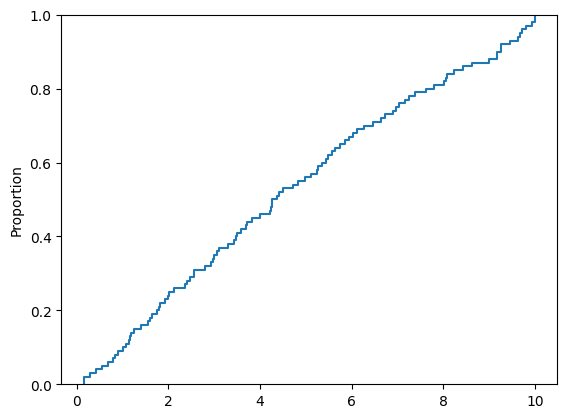

In [17]:
def drawdemp(X):
    sn.ecdfplot(X)
    plt.show()

drawdemp(Y)